# Children's Speech ASR — Whisper-small Fine-tuning

This notebook fine-tunes `openai/whisper-small` on the COMP0197 children's speech dataset and
evaluates using **Word Error Rate (WER)**.

Two uncertainty modes are provided:
1. **Beam-search confidence** — token-level max-probability and entropy from the beam scores
   (aleatoric proxy, no extra forward passes)
2. **Monte Carlo Dropout** — N stochastic decoding passes to separate epistemic from aleatoric
   uncertainty (same decomposition as the Wav2Vec2 notebook)

**GenAI statement**: Code assistance provided by Claude (Anthropic). All outputs were reviewed
and verified for technical accuracy by the student.

---
Dataset: https://www.drivendata.org/competitions/308/childrens-word-asr/page/980/

In [ ]:
# Set the cache directory, only needed when using UCl lab machines
import os
os.environ['HF_HOME'] = '/cs/student/project_msc/2025/dsml/nmxian/huggingface_cache'
os.environ['TORCH_HOME'] = '/cs/student/project_msc/2025/dsml/nmxian/torch_cache'
os.environ['KAGGLEHUB_CACHE'] = '/cs/student/project_msc/2025/dsml/nmxian/kaggle_cache'

In [ ]:
# ── 0. Install required libraries ────────────────────────────────────────────
#!pip install -q transformers datasets soundfile librosa jiwer scikit-learn accelerate evaluate numpy pandas matplotlib

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, json, random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import soundfile as sf
import librosa
import jiwer

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

print(f"torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")

torch  : 2.8.0+cu128
CUDA   : True


In [3]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
DATA_ROOT        = Path("/cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2")
MODEL_NAME       = "openai/whisper-small"
SAMPLE_RATE      = 16_000       # Whisper always expects 16 kHz
MAX_DURATION_SEC = 30.0         # Whisper input window is 30 s; drop longer clips

# Set to None to use full dataset; reduce for quick experiments
NUM_TRAIN_SAMPLES = 5_000
NUM_EVAL_SAMPLES  = 1_000

BATCH_SIZE    = 8
LEARNING_RATE = 1e-5
NUM_EPOCHS    = 3
OUTPUT_DIR    = str(DATA_ROOT / "whisper_finetuned")
SEED          = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


In [4]:
# ── 3. Load & explore dataset ─────────────────────────────────────────────────
with open(DATA_ROOT / "train_word_transcripts.jsonl") as f:
    raw_data = [json.loads(line) for line in f]

df = pd.DataFrame(raw_data)
print(f"Total utterances : {len(df):,}")
print(f"Age distribution :\n{df['age_bucket'].value_counts()}")
print(f"\nDuration stats (sec):\n{df['audio_duration_sec'].describe().round(2)}")

Total utterances : 95,572
Age distribution :
age_bucket
8-11    73970
5-7     11490
3-4     10112
Name: count, dtype: int64

Duration stats (sec):
count    95572.00
mean         6.98
std          9.28
min          0.08
25%          1.78
50%          4.09
75%          9.05
max       1348.69
Name: audio_duration_sec, dtype: float64


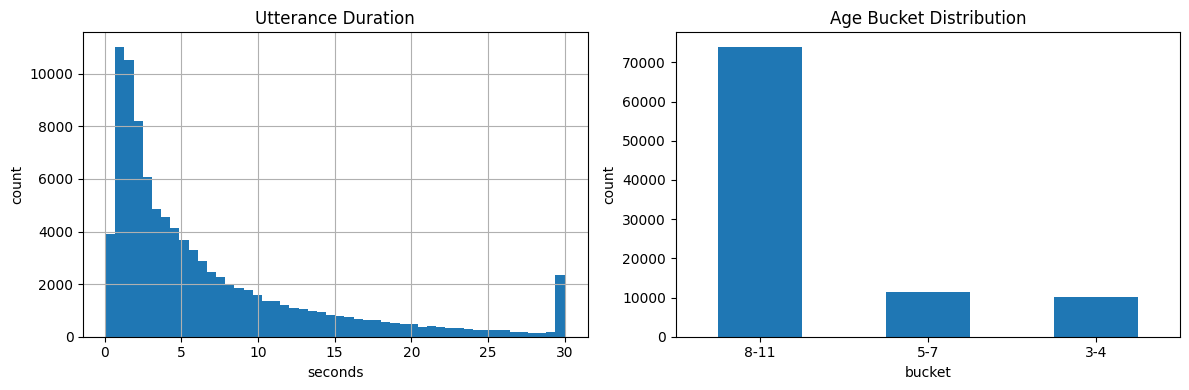

In [5]:
# Duration + age visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['audio_duration_sec'].clip(upper=30).hist(bins=50, ax=axes[0])
axes[0].set(title='Utterance Duration', xlabel='seconds', ylabel='count')
df['age_bucket'].value_counts().plot.bar(ax=axes[1], rot=0)
axes[1].set(title='Age Bucket Distribution', xlabel='bucket', ylabel='count')
plt.tight_layout()
plt.savefig(DATA_ROOT / "eda_whisper.png", dpi=100)
plt.show()

In [6]:
# ── 4. Filter & split ─────────────────────────────────────────────────────────
df_filtered = df[df['audio_duration_sec'] <= MAX_DURATION_SEC].reset_index(drop=True)
data = df_filtered.to_dict('records')

# 3-way split: 80% train / 10% eval (used during training) / 10% test (zero-shot baseline)
train_data, temp = train_test_split(data, test_size=0.2, random_state=SEED)
eval_data, test_data = train_test_split(temp, test_size=0.5, random_state=SEED)

if NUM_TRAIN_SAMPLES:
    train_data = train_data[:NUM_TRAIN_SAMPLES]
if NUM_EVAL_SAMPLES:
    eval_data = eval_data[:NUM_EVAL_SAMPLES]

print(f'Train : {len(train_data):,}')
print(f'Eval  : {len(eval_data):,}')
print(f'Test  : {len(test_data):,}')


Train : 5,000
Eval  : 1,000


In [7]:
# ── 5. Audio utility ──────────────────────────────────────────────────────────
def load_audio(audio_path_rel: str) -> np.ndarray:
    """Load a FLAC file and return a mono float32 array at SAMPLE_RATE."""
    path = DATA_ROOT / audio_path_rel
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio.astype(np.float32),
                                 orig_sr=sr, target_sr=SAMPLE_RATE)
    return audio.astype(np.float32)

In [8]:
# ── 6. Processor ──────────────────────────────────────────────────────────────
# WhisperProcessor = WhisperFeatureExtractor + WhisperTokenizer
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language="English", task="transcribe"
)
print("Vocab size:", processor.tokenizer.vocab_size)

Vocab size: 50258


In [9]:
# ── 7. PyTorch Dataset ────────────────────────────────────────────────────────
class WhisperSpeechDataset(Dataset):
    """
    Returns log-mel input_features (fixed 30 s window) and tokenised labels.
    Whisper's feature extractor pads / truncates to exactly 30 s internally.
    """
    def __init__(self, records, processor):
        self.records   = records
        self.processor = processor

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item  = self.records[idx]
        audio = load_audio(item['audio_path'])

        # Log-mel spectrogram — shape (80, 3000) for a 30 s window
        feat = self.processor.feature_extractor(
            audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        )
        input_features = feat.input_features.squeeze(0)    # (80, 3000)

        # Tokenise transcript (lowercase, no BOS/EOS — Seq2SeqTrainer adds them)
        text   = item['orthographic_text'].lower()
        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze(0)

        return {
            "input_features" : input_features,
            "labels"         : labels,
        }

In [10]:
# ── 8. Data collator ──────────────────────────────────────────────────────────
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """
    - input_features : already fixed length (80 × 3000) — just stack
    - labels         : variable length — right-pad with -100
    """
    processor: WhisperProcessor

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = torch.stack([f["input_features"] for f in features])

        label_list = [f["labels"] for f in features]
        max_len    = max(l.shape[0] for l in label_list)
        labels     = torch.full((len(label_list), max_len), -100, dtype=torch.long)
        for i, lbl in enumerate(label_list):
            labels[i, :lbl.shape[0]] = lbl

        return {
            "input_features" : input_features,
            "labels"         : labels,
        }

In [11]:
# ── 9. Model ──────────────────────────────────────────────────────────────────
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Force English transcription (suppress other language tokens during generation)
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="english", task="transcribe"
)
model.config.forced_decoder_ids   = forced_decoder_ids
model.config.suppress_tokens      = []
model.generation_config.language  = "english"
model.generation_config.task      = "transcribe"
model.generation_config.forced_decoder_ids = forced_decoder_ids

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)")

Total params     : 241,734,912
Trainable params : 240,582,912  (99.5%)


In [12]:
# ── 10. WER metric ────────────────────────────────────────────────────────────
_transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.ReduceToListOfListOfWords(),
])

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_strs  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_strs = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = jiwer.process_words(
        label_strs, pred_strs,
        reference_transform=_transform,
        hypothesis_transform=_transform,
    ).wer
    return {"wer": wer}

In [ ]:
# ── 10b. Zero-shot WER (before any fine-tuning) ──────────────────────────────
# Evaluate the base whisper-small on the held-out test set to establish a baseline.
# Uses all of test_data (not a capped subset) for an unbiased estimate.
model.eval()

def transcribe_zero(audio, mdl, proc, max_new_tokens=225):
    feat = proc.feature_extractor(audio, sampling_rate=SAMPLE_RATE, return_tensors='pt')
    input_features = feat.input_features.to(device)
    with torch.no_grad():
        ids = mdl.generate(input_features=input_features, max_new_tokens=max_new_tokens)
    return proc.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

zs_preds, zs_refs = [], []
for item in test_data:
    audio = load_audio(item['audio_path'])
    zs_preds.append(transcribe_zero(audio, model, processor))
    zs_refs.append(item['orthographic_text'])

wer_zero_shot = wer_score(zs_refs, zs_preds)
print(f'Zero-shot WER (n={len(test_data)} test samples): {wer_zero_shot:.4f}')


In [14]:
# ── 11. Training ──────────────────────────────────────────────────────────────
train_dataset = WhisperSpeechDataset(train_data, processor)
eval_dataset  = WhisperSpeechDataset(eval_data,  processor)
collator      = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = OUTPUT_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = 1,
    warmup_steps                = 200,
    num_train_epochs            = NUM_EPOCHS,
    learning_rate               = LEARNING_RATE,
    fp16                        = torch.cuda.is_available(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "wer",
    greater_is_better           = False,
    predict_with_generate       = True,
    generation_max_length       = 225,
    logging_steps               = 50,
    report_to                   = "none",
    dataloader_num_workers      = 4,
    seed                        = SEED,
)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    data_collator   = collator,
    compute_metrics = compute_metrics,
    tokenizer       = processor.feature_extractor,
)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Model saved to", OUTPUT_DIR)

/tmp/ipykernel_3654932/2036732767.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Wer
1,0.325500,0.317147,0.167186
2,0.114700,0.317085,0.130225
3,0.046600,0.340893,0.127766


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/cs/student/project_msc/2025/dsml/nmxian/my-notebook/myenv/lib64/python3.9/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Model saved to /cs/student/project_msc/2025/dsml/nmxian/comp0197-cw2/whisper_finetuned


Overall WER : 0.1278


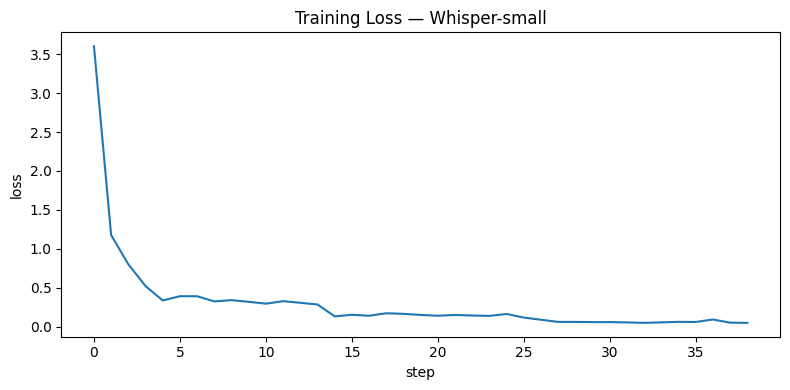

In [15]:
# ── 12. Evaluation ────────────────────────────────────────────────────────────
eval_results = trainer.evaluate()
print(f"Overall WER : {eval_results['eval_wer']:.4f}")

log_history = pd.DataFrame(trainer.state.log_history)
if 'loss' in log_history.columns:
    plt.figure(figsize=(8, 4))
    log_history.dropna(subset=['loss'])['loss'].plot()
    plt.title('Training Loss — Whisper-small')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "whisper_train_loss.png", dpi=100)
    plt.show()

  Age 3-4   → WER = 0.5052  (n=121)
  Age 5-7   → WER = 0.1608  (n=114)
  Age 8-11  → WER = 0.0979  (n=765)


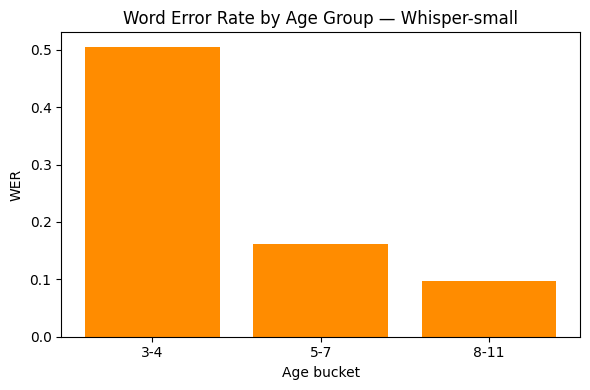

In [16]:
# ── 13. WER by age bucket ─────────────────────────────────────────────────────
model.eval()

def transcribe_whisper(audio, model, processor, max_new_tokens=225):
    """Greedy transcription (no beam, fast)."""
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)
    with torch.no_grad():
        ids = model.generate(input_features=input_features, max_new_tokens=max_new_tokens)
    return processor.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

age_wer = {}
for bucket in ['3-4', '5-7', '8-11']:
    bucket_eval = [d for d in eval_data if d['age_bucket'] == bucket]
    if not bucket_eval:
        continue
    preds, refs = [], []
    for item in bucket_eval[:200]:
        audio = load_audio(item['audio_path'])
        pred  = transcribe_whisper(audio, model, processor)
        preds.append(pred)
        refs.append(item['orthographic_text'])
    wer = jiwer.process_words(refs, preds,
                    reference_transform=_transform,
                    hypothesis_transform=_transform).wer
    age_wer[bucket] = wer
    print(f"  Age {bucket:5s} → WER = {wer:.4f}  (n={len(bucket_eval)})")

plt.figure(figsize=(6, 4))
plt.bar(age_wer.keys(), age_wer.values(), color='darkorange')
plt.xlabel('Age bucket')
plt.ylabel('WER')
plt.title('Word Error Rate by Age Group — Whisper-small')
plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_wer_by_age.png", dpi=100)
plt.show()

In [20]:
# ── 14. Uncertainty method 1: Beam-search token confidence ───────────────────
#
# During beam-search generation Whisper returns per-step score tensors.
# Converting each score to a softmax distribution gives a token-level
# probability distribution — its entropy is an aleatoric uncertainty proxy.
#
#   p_t(v) = softmax(score_t)_v
#   H_t    = −Σ_v p_t(v) log p_t(v)    (token-level entropy)
#   conf_t = max_v p_t(v)               (token-level confidence)

def beam_confidence(
    audio, model, processor,
    num_beams=5, max_new_tokens=225
):
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    model.eval()
    with torch.no_grad():
        out = model.generate(
            input_features,
            num_beams          = num_beams,
            return_dict_in_generate = True,
            output_scores      = True,
            max_new_tokens     = max_new_tokens,
        )

    # out.scores is a tuple of (batch, vocab) tensors, one per generated token
    scores = torch.stack(out.scores, dim=1)          # (batch, T_gen, vocab)
    probs  = torch.softmax(scores, dim=-1)           # (batch, T_gen, vocab)

    token_conf    = probs[0].max(dim=-1).values      # (T_gen,)
    token_entropy = -(probs[0] * torch.log(probs[0] + 1e-10)).sum(dim=-1)  # (T_gen,)

    transcription = processor.tokenizer.decode(
        out.sequences[0], skip_special_tokens=True
    )

    return {
        "transcription"   : transcription,
        "mean_confidence" : token_conf.mean().item(),
        "mean_entropy"    : token_entropy.mean().item(),
        "token_conf"      : token_conf.cpu().numpy(),
        "token_entropy"   : token_entropy.cpu().numpy(),
    }

In [21]:
# ── 15. Uncertainty method 2: Monte Carlo Dropout ────────────────────────────
#
# Whisper's encoder has dropout layers.  Setting model.train() activates them
# while calling generate() in no_grad mode; repeated calls yield a sample
# of encoder representations from which epistemic uncertainty is estimated.
#
# NOTE: Only the encoder is stochastic here (encoder dropout); the decoder
# is run greedily for speed.  For full MC-Dropout include decoder dropout too.

def mc_dropout_uncertainty(
    audio, model, processor,
    n_passes=20, max_new_tokens=225
):
    feat = processor.feature_extractor(
        audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    )
    input_features = feat.input_features.to(device)

    model.train()          # activate dropout

    all_seqs   = []
    all_scores = []
    with torch.no_grad():
        for _ in range(n_passes):
            out = model.generate(
                input_features,
                return_dict_in_generate=True,
                output_scores=True,
                max_new_tokens=max_new_tokens,
            )
            all_seqs.append(
                processor.tokenizer.decode(out.sequences[0], skip_special_tokens=True)
            )
            # Pad token-level scores to the same length before stacking
            scores = torch.stack(out.scores, dim=0).squeeze(1)   # (T_gen, vocab)
            all_scores.append(scores)

    model.eval()

    # Find max seq length across passes for alignment
    max_T  = max(s.shape[0] for s in all_scores)
    V      = all_scores[0].shape[-1]
    # Pad with uniform log-probs so shape is consistent
    padded = torch.full((n_passes, max_T, V), -np.log(V), dtype=torch.float)
    for i, s in enumerate(all_scores):
        padded[i, :s.shape[0]] = s

    probs  = torch.softmax(padded, dim=-1)       # (N, T, V)
    mean_p = probs.mean(dim=0)                   # (T, V)

    # Predictive entropy
    pred_H = -(mean_p * torch.log(mean_p + 1e-10)).sum(dim=-1)             # (T,)
    # Aleatoric (expected entropy per pass)
    alea_H = -(probs * torch.log(probs + 1e-10)).sum(dim=-1).mean(dim=0)   # (T,)
    # Epistemic (mutual information)
    epis_H = pred_H - alea_H                                               # (T,)

    # Most frequent transcription across passes
    from collections import Counter
    transcription = Counter(all_seqs).most_common(1)[0][0]

    return {
        "transcription"        : transcription,
        "predictive_entropy"   : pred_H.mean().item(),
        "aleatoric_uncertainty": alea_H.mean().item(),
        "epistemic_uncertainty": epis_H.mean().item(),
        "pass_transcriptions"  : all_seqs,
        "token_predictive_H"   : pred_H.cpu().numpy(),
    }

In [22]:
# ── 16. Uncertainty analysis on evaluation samples ────────────────────────────
N_UNCERTAINTY_SAMPLES = 10
sample_records = random.sample(eval_data, N_UNCERTAINTY_SAMPLES)

results_beam, results_mc = [], []
for item in sample_records:
    audio = load_audio(item['audio_path'])
    ref   = item['orthographic_text']

    # ---- beam confidence
    b = beam_confidence(audio, model, processor, num_beams=5)
    results_beam.append({
        "reference"       : ref,
        "prediction"      : b["transcription"],
        "wer"             : jiwer.process_words([ref], [b["transcription"]],
                               reference_transform=_transform,
                               hypothesis_transform=_transform).wer,
        "mean_confidence" : b["mean_confidence"],
        "mean_entropy"    : b["mean_entropy"],
        "age_bucket"      : item["age_bucket"],
    })

    # ---- MC dropout
    m = mc_dropout_uncertainty(audio, model, processor, n_passes=10)
    results_mc.append({
        "reference"   : ref,
        "prediction"  : m["transcription"],
        "wer"         : jiwer.process_words([ref], [m["transcription"]],
                           reference_transform=_transform,
                           hypothesis_transform=_transform).wer,
        "pred_H"      : m["predictive_entropy"],
        "aleatoric"   : m["aleatoric_uncertainty"],
        "epistemic"   : m["epistemic_uncertainty"],
        "age_bucket"  : item["age_bucket"],
    })

beam_df = pd.DataFrame(results_beam)
mc_df   = pd.DataFrame(results_mc)
print("Beam confidence results:")
print(beam_df[['reference','prediction','wer','mean_confidence','mean_entropy']].to_string())
print("\nMC-Dropout results:")
print(mc_df[['reference','prediction','wer','pred_H','aleatoric','epistemic']].to_string())

Beam confidence results:
                                                                                                                                                                                                                                                                                  reference                                                                                                                                                                                                                                                                                 prediction       wer  mean_confidence  mean_entropy
0                                                                                                                                                                                                                                                               uh huh he was sleeping like                                                                                    

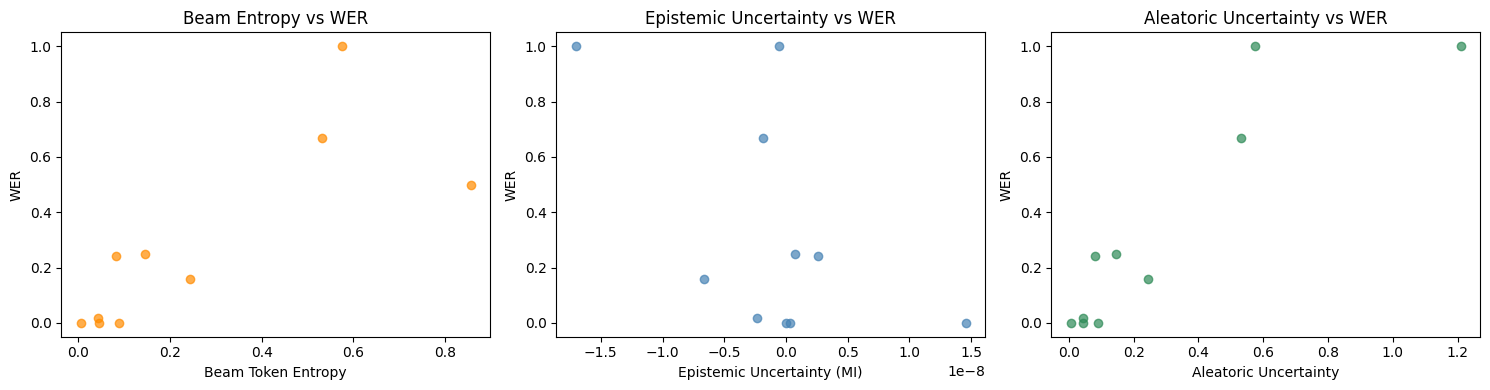

Correlation with WER (beam):
mean_confidence   -0.839693
mean_entropy       0.800640
Name: wer, dtype: float64

Correlation with WER (MC-Dropout):
pred_H       0.899415
aleatoric    0.899415
epistemic   -0.548964
Name: wer, dtype: float64


In [23]:
# ── 17. Uncertainty vs WER visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(beam_df['mean_entropy'], beam_df['wer'], alpha=0.7, color='darkorange')
axes[0].set(xlabel='Beam Token Entropy', ylabel='WER',
            title='Beam Entropy vs WER')

axes[1].scatter(mc_df['epistemic'], mc_df['wer'], alpha=0.7, color='steelblue')
axes[1].set(xlabel='Epistemic Uncertainty (MI)', ylabel='WER',
            title='Epistemic Uncertainty vs WER')

axes[2].scatter(mc_df['aleatoric'], mc_df['wer'], alpha=0.7, color='seagreen')
axes[2].set(xlabel='Aleatoric Uncertainty', ylabel='WER',
            title='Aleatoric Uncertainty vs WER')

plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_uncertainty.png", dpi=100)
plt.show()

print("Correlation with WER (beam):")
print(beam_df[['mean_confidence','mean_entropy','wer']].corr()['wer'].drop('wer'))
print("\nCorrelation with WER (MC-Dropout):")
print(mc_df[['pred_H','aleatoric','epistemic','wer']].corr()['wer'].drop('wer'))

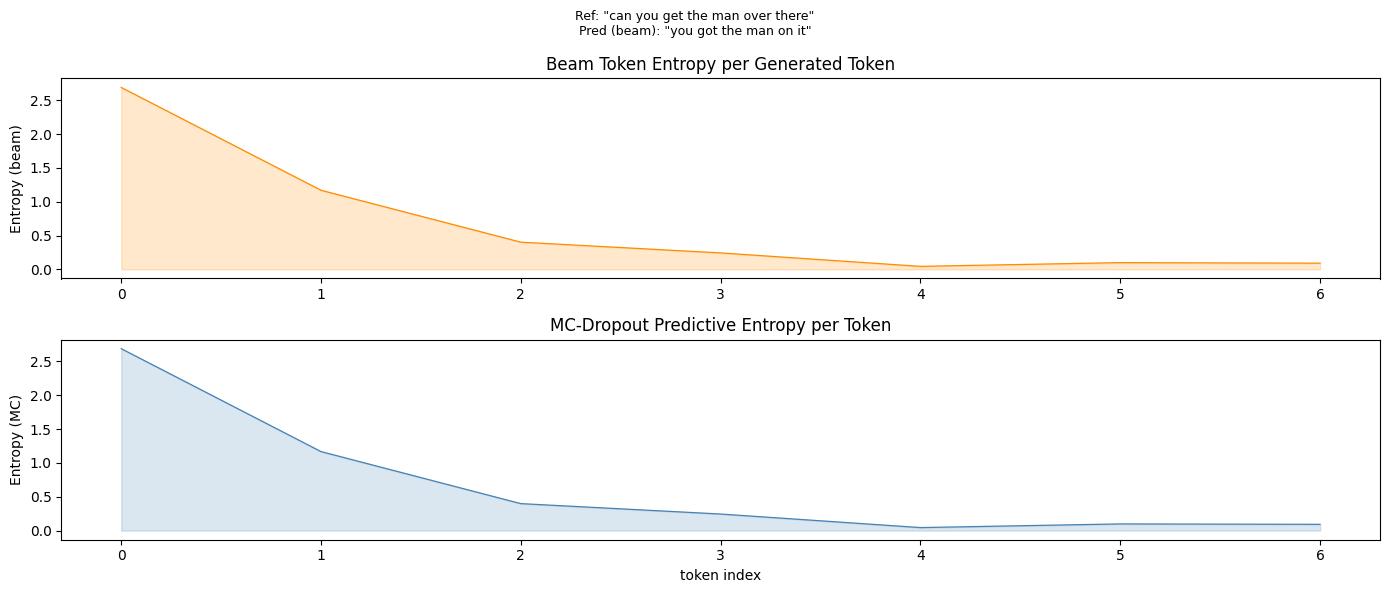

In [24]:
# ── 18. Token-level uncertainty for a single example ─────────────────────────
sample = random.choice(eval_data)
audio  = load_audio(sample['audio_path'])

b_out = beam_confidence(audio, model, processor, num_beams=5)
m_out = mc_dropout_uncertainty(audio, model, processor, n_passes=20)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(b_out['token_entropy'], linewidth=0.9, color='darkorange')
axes[0].fill_between(range(len(b_out['token_entropy'])),
                     b_out['token_entropy'], alpha=0.2, color='darkorange')
axes[0].set(ylabel='Entropy (beam)', title='Beam Token Entropy per Generated Token')

axes[1].plot(m_out['token_predictive_H'], linewidth=0.9, color='steelblue')
axes[1].fill_between(range(len(m_out['token_predictive_H'])),
                     m_out['token_predictive_H'], alpha=0.2, color='steelblue')
axes[1].set(xlabel='token index', ylabel='Entropy (MC)',
            title='MC-Dropout Predictive Entropy per Token')

fig.suptitle(
    f'Ref: "{sample["orthographic_text"]}"\n'
    f'Pred (beam): "{b_out["transcription"]}"',
    fontsize=9
)
plt.tight_layout()
plt.savefig(DATA_ROOT / "whisper_token_uncertainty.png", dpi=100)
plt.show()

In [25]:
# ── 19. Summary ───────────────────────────────────────────────────────────────
print("=" * 55)
print("SUMMARY — Whisper-small Children's Speech ASR")
print("=" * 55)
print(f"Model          : {MODEL_NAME}")
print(f"Train samples  : {len(train_data):,}")
print(f"Eval  samples  : {len(eval_data):,}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Overall WER    : {eval_results['eval_wer']:.4f}")
for bucket, wer in age_wer.items():
    print(f"  WER [{bucket}]    : {wer:.4f}")
print()
print(f"Beam mean confidence : {beam_df['mean_confidence'].mean():.4f}")
print(f"Beam mean entropy    : {beam_df['mean_entropy'].mean():.4f}")
print(f"MC-Dropout pred_H    : {mc_df['pred_H'].mean():.4f}")
print(f"MC-Dropout epistemic : {mc_df['epistemic'].mean():.4f}")
print(f"MC-Dropout aleatoric : {mc_df['aleatoric'].mean():.4f}")

SUMMARY — Whisper-small Children's Speech ASR
Model          : openai/whisper-small
Train samples  : 5,000
Eval  samples  : 1,000
Epochs         : 3
Overall WER    : 0.1278
  WER [3-4]    : 0.5052
  WER [5-7]    : 0.1608
  WER [8-11]    : 0.0979

Beam mean confidence : 0.9372
Beam mean entropy    : 0.2617
MC-Dropout pred_H    : 0.2972
MC-Dropout epistemic : -0.0000
MC-Dropout aleatoric : 0.2972
